In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df_assessable = pd.read_csv('assessable-income-of-individuals.csv')

# Inspect the dataframe
print("Assessable Income Data:")
print(df_assessable.head())
print(df_assessable.info())

# Load the other datasets to see if they are needed
df_tax_group = pd.read_csv('assessable-income-of-individuals-by-tax-group.csv')
df_income_type = pd.read_csv('income-of-individuals-by-income-type.csv')
df_income_type_tax = pd.read_csv('income-of-individuals-by-income-type-and-tax-group.csv')

Assessable Income Data:
   year_of_assessment  no_of_indv_assessed  total_income  donations  \
0                2004              1734218      71878947     254217   
1                2005              1528861      71594148     247025   
2                2006              1461040      75480305     323978   
3                2007              1522175      84724808     282038   
4                2008              1616707      98848536     357352   

   assessable_income  
0           71624730  
1           71347123  
2           75156326  
3           84442770  
4           98491184  
<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   year_of_assessment   16 non-null     int64
 1   no_of_indv_assessed  16 non-null     int64
 2   total_income         16 non-null     int64
 3   donations            16 non-null     int64
 4   assessable_income    16 non

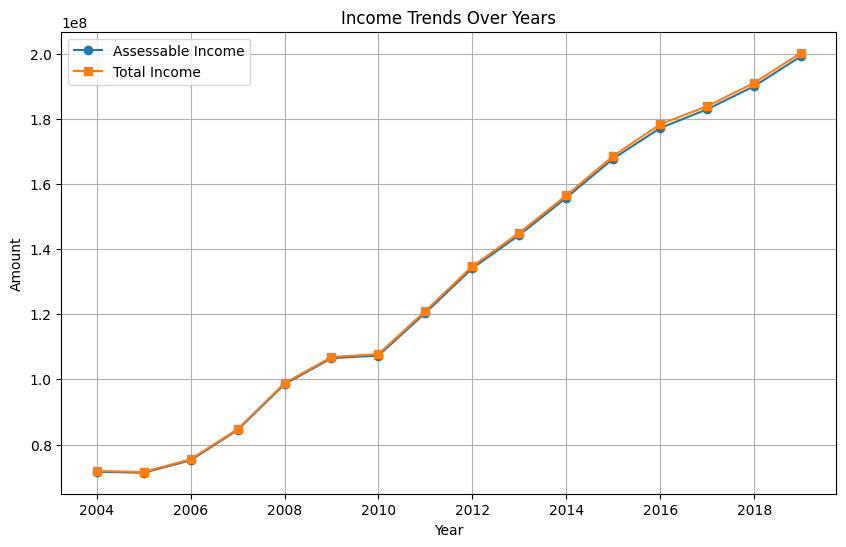

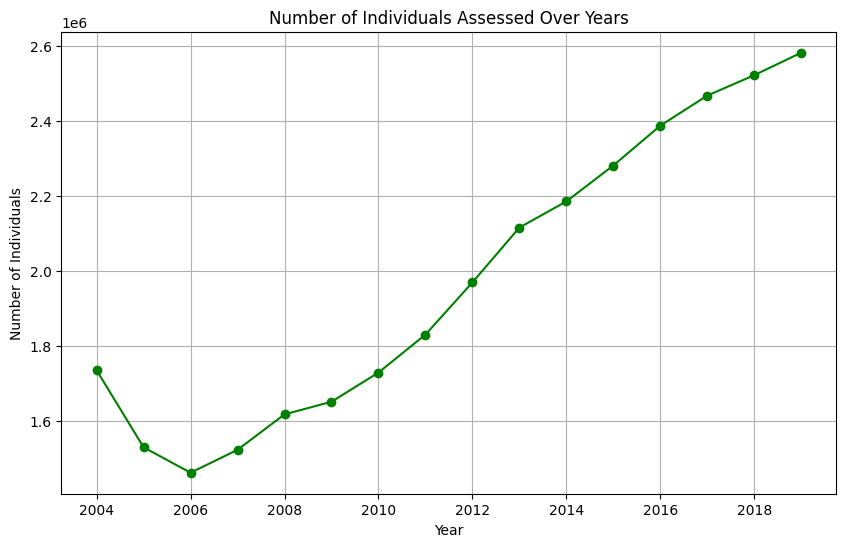

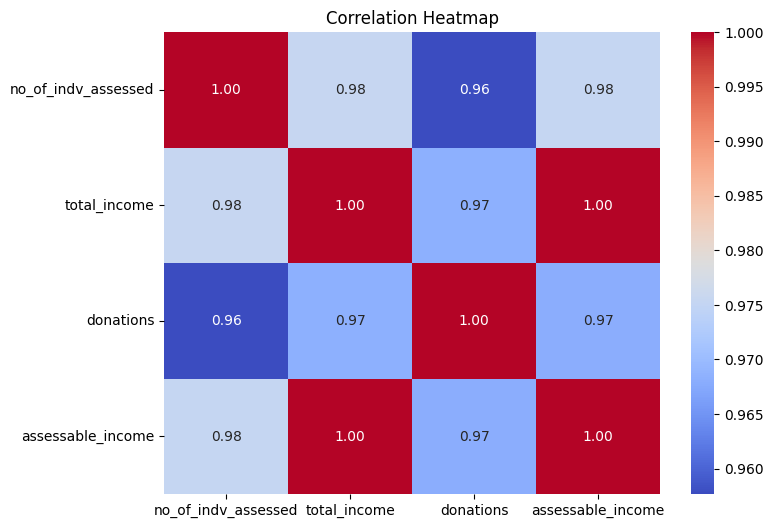

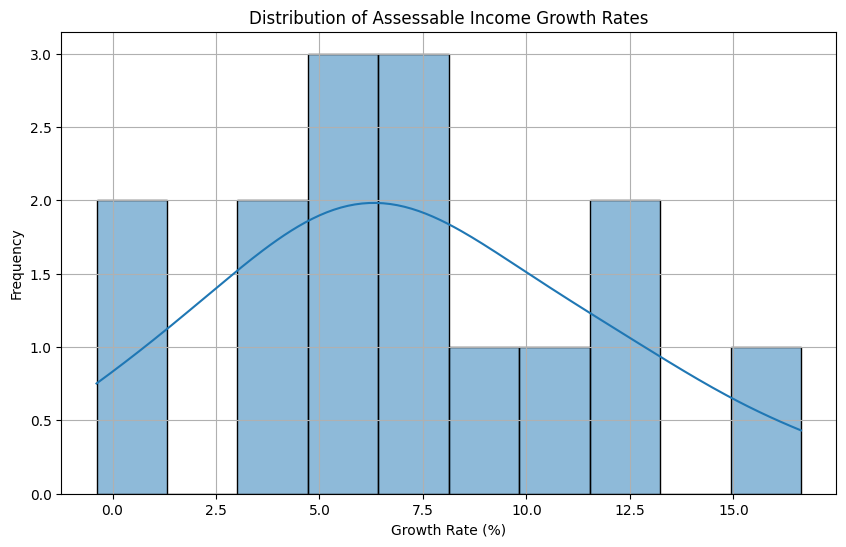

In [2]:
# 1. Income and Volume Trends
plt.figure(figsize=(10, 6))
plt.plot(df_assessable['year_of_assessment'], df_assessable['assessable_income'], marker='o', label='Assessable Income')
plt.plot(df_assessable['year_of_assessment'], df_assessable['total_income'], marker='s', label='Total Income')
plt.title('Income Trends Over Years')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.savefig('income_trends.png')

plt.figure(figsize=(10, 6))
plt.plot(df_assessable['year_of_assessment'], df_assessable['no_of_indv_assessed'], marker='o', color='green')
plt.title('Number of Individuals Assessed Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Individuals')
plt.grid(True)
plt.savefig('volume_trends.png')

# 2. Correlation Heatmap
corr_matrix = df_assessable[['no_of_indv_assessed', 'total_income', 'donations', 'assessable_income']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

# 3. "Return" (Growth Rate) Distribution
df_assessable['growth_rate'] = df_assessable['assessable_income'].pct_change() * 100
# Drop the first row which will have NaN
growth_rates = df_assessable['growth_rate'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(growth_rates, kde=True, bins=10)
plt.title('Distribution of Assessable Income Growth Rates')
plt.xlabel('Growth Rate (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig('growth_distribution.png')